# House Price Modelling and ML Pipeline

## Objectives
* Build a machine learning pipeline to predict house sale prices in Ames, Iowa
* Automate feature engineering, missing value handling, transformations, encoding, and model fitting
* Compare alternative ML models and assess predictive power

## Inputs
* `house_prices_records.csv` data located at outputs/datasets/collection
* Dataset on customer's inherited houses' characteristics

## Outputs
- Trained and evaluated ML pipelines.
- Hyperparameter tuning results.
- Actual vs Predicted plots for train and test sets.
- A saved fitted pipeline for deployment in the Streamlit dashboard.
- Predicted sale prices for the inherited houses.

## Feature Engineering Design (from previous NB)

| Variable        | Action                                                            |
|-----------------|-------------------------------------------------------------------|
| `SalePrice`     | Logarithmic transformation                                        |
| `1stFlrSF`      | Logarithmic transformation                                        |
| `2ndFlrSF`      | (1) Replace missing with zero                                     |
|                 | (2) Create `Has2ndFlr`                                            |
|                 | (3) Create `HasExtraLivArea`                                      |
| `GrLivArea`     | Logarithmic transformation                                        |
| `BsmtFinSF1`    | (1) Log1p transformation                                          |
|                 | (2) Create `HasBsmtFin`                                       |  
| `BsmtUnfSF`     | (1) Log1p transformation                                          |
|                 | (2) Create `HasBsmtUnf`                                           | 
| `BsmtFinType1`  | (1) Replace missing with "No_basement" if TotalBsmtSF==0          |
|                 | (2) Replace missing with "Unf" if `BsmtUnfSF>0` & `BsmtFinSF1==0` |
|                 | (3) Create `MissingBsmtFinType1` variable                         |
|                 | (4) Replace remaining missing with mode                           |
|                 | (5) Create set of dummies based on categories                     |
| `BsmtExposure`  | (1) Replace missing with "No_basement" if TotalBsmtSF==0          |
|                 | (2) Replace remaining missing with "No" if TotalBsmtSF>0          | 
|                 | (3) Create set of dummies based on categories                     |
| `TotalBsmtSF`   | (1) Log1p transformation                                          |
|                 | (2) Create `HasBasement`                                          |
| `LotFrontage`   | (1) Create `MissingLotFrontage` variable                          |
|                 | (2) Replace missing with zero                                     |
|                 | (3) Log1p transformation                                          |
| `LotArea`       | (1) Logarithmic transformation                                    |
|                 | (2) Create `HasLargeLotArea`                                      |
|                 | (3) Create `HasSmallLotArea`                                      |
| `BedroomAbvGr`  | (1) Create `MissingBedroomAbvGr` variable                         |
|                 | (2a) Replace missing with mean; Substitute: Impute with mode      |
|                 | (2b) Replace missing with mode; Substitute: Impute with mean      |
| `GarageArea`    | (1) Create `HasGarage`                                            |
|                 | (2) Log1p transformation                                          |
| `GarageFinish`  | (1) Replace missing with "No_garage" if `GarageArea`==0           |
|                 | (2) Replace remaining missing with "Missing"                      |
|                 | (3) Create set of dummies based on categories                     |
| `MasVnrArea`    | (1) Create `MissingMasVnrArea` variable                           |
|                 | (2) Replace missing with zero                                     |
|                 | (3) Log1p transformation                                          |
|                 | (4) Create `HasMasVnr`                                            |
| `GarageYrBlt`   | (1) Create `MissingGarageYrBlt`                                   |
|                 | (2) Replace missing with zero                                     |
| `EnclosedPorch` | (1) Replace missing with zero                                     |
|                 | (2) Create `TotalPorch` = `EnclosedPorch` + `OpenPorchSF`         |
|                 | (3) Create `HasEnclosedPorch`                                     |
| `OpenPorchSF`   | Create `HasOpenPorch`                                             |
| `KitchenQual`   | Create set of dummies based on categories                         |
| `WoodDeckSF`    | (1) Replace missing with zero                                     |
|                 | (2) Create `HasWoodDeck`                                          |
| `OverallCond`   | No change; include as it is provided in data                      |
| `OverallQual`   | No change; include as it is provided in data                      |
| `YearBuilt`     | No change; include as it is provided in data                      |
|                 | Create `BuiltPre1950` for truncation of `YearRemodAdd` at 1950    |
| `YearRemodAdd`  | Include together with `BuiltPre1950`                              |



## Imports and Setup

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge

## Change Working Directory

We will change the directory to the project level. 

In [3]:
project_root = Path.cwd()
# Move up until we find the project root (identified by a folder/file as marker)
while not (project_root / ".git").exists():
    project_root = project_root.parent

os.chdir(project_root)

print("Working directory set to:", project_root)

Working directory set to: /Users/mehtap/Documents/GitHub/heritage-housing-issues


## Load Data

Load the `house_prices_records` data.

In [4]:
df = pd.read_csv('outputs/datasets/collection/house_prices_records.csv')
df.head()

,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500
3,961,NaN,NaN,No,216,ALQ,540,NaN,642,Unf,...,60.0,0.0,35,5,7,756,NaN,1915,1970,140000
4,1145,NaN,4.0,Av,655,GLQ,490,0.0,836,RFn,...,84.0,350.0,84,5,8,1145,NaN,2000,2000,250000


In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   1stFlrSF       1460 non-null   int64  
 1   2ndFlrSF       1374 non-null   float64
 2   BedroomAbvGr   1361 non-null   float64
 3   BsmtExposure   1422 non-null   object 
 4   BsmtFinSF1     1460 non-null   int64  
 5   BsmtFinType1   1315 non-null   object 
 6   BsmtUnfSF      1460 non-null   int64  
 7   EnclosedPorch  136 non-null    float64
 8   GarageArea     1460 non-null   int64  
 9   GarageFinish   1225 non-null   object 
 10  GarageYrBlt    1379 non-null   float64
 11  GrLivArea      1460 non-null   int64  
 12  KitchenQual    1460 non-null   object 
 13  LotArea        1460 non-null   int64  
 14  LotFrontage    1201 non-null   float64
 15  MasVnrArea     1452 non-null   float64
 16  OpenPorchSF    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  OverallQ

## Define target and predictors

Based on the EDA of the previous notebook, `SalePrice` will be modelled in logarithmic form. 

In [6]:
target_variable = 'SalePrice'
X = df.drop(columns=[target_variable]).copy()
y = np.log(df[target_variable]).copy()

## Split Data into Train and Test Samples

House Prices data will be split into train and test samples to be able to choose the modelling approach that yields best model performance. Test size is chosen to be one-fifth of the overall sample.   

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=34
)

print(X_train.shape, X_test.shape)

(1168, 23) (292, 23)


## Custom Feature Engineering Transformer 

In [8]:
class FeatureEngineerHPData(BaseEstimator, TransformerMixin):
    def __init__(self, lotarea_large_q=0.99, lotarea_small_q=0.01,
                 bedroom_impute_strategy="mean"):
        self.lotarea_large_q = lotarea_large_q
        self.lotarea_small_q = lotarea_small_q
        self.bedroom_impute_strategy = bedroom_impute_strategy

    def fit(self, X, y=None):
        X = X.copy()

        # LotArea thresholds learned from training data
        self.large_lot_threshold_ = X['LotArea'].quantile(self.lotarea_large_q)
        self.small_lot_threshold_ = X['LotArea'].quantile(self.lotarea_small_q)

        # Modes learned from training data
        self.bsmtfintype1_mode_ = X['BsmtFinType1'].mode(dropna=True)[0]
        self.bedroom_mode_ = X['BedroomAbvGr'].mode(dropna=True)[0]

        # Mean learned from training data
        self.bedroom_mean_ = X['BedroomAbvGr'].mean()

        if self.bedroom_impute_strategy == "mean":
            self.bedroom_fill_value_ = self.bedroom_mean_
        elif self.bedroom_impute_strategy == "mode":
            self.bedroom_fill_value_ = self.bedroom_mode_
        else:
            raise ValueError("bedroom_impute_strategy must be 'mean' or 'mode'")

        return self

    def transform(self, X):
        X = X.copy()


        # =============================
        # Create missingness indicators
        # =============================
        # Create missingness indicators before imputations
        X['MissingLotFrontage'] = X['LotFrontage'].isna().astype(int)
        X['MissingMasVnrArea'] = X['MasVnrArea'].isna().astype(int)
        X['MissingGarageYrBlt'] = X['GarageYrBlt'].isna().astype(int)
        X['MissingBedroomAbvGr'] = X['BedroomAbvGr'].isna().astype(int)
        # Create missingness indicator after imputations 
        X['MissingBsmtFinType1'] = 0

        # ===============================
        # Replace missing cells with zero
        # ===============================
        X['2ndFlrSF'] = X['2ndFlrSF'].fillna(0)
        X['LotFrontage'] = X['LotFrontage'].fillna(0)
        X['MasVnrArea'] = X['MasVnrArea'].fillna(0)
        X['GarageYrBlt'] = X['GarageYrBlt'].fillna(0)
        X['EnclosedPorch'] = X['EnclosedPorch'].fillna(0)
        X['WoodDeckSF'] = X['WoodDeckSF'].fillna(0)

        #============================
        # Impute missing BedroomAbvGr
        #============================
        X['BedroomAbvGr'] = X['BedroomAbvGr'].fillna(self.bedroom_fill_value_)

        # ======================================
        # Create binary house feature indicators
        # ======================================
        X['Has2ndFlr'] = (X['2ndFlrSF'] > 0).astype(int)
        X['HasExtraLivArea'] = (X['GrLivArea'] > (X['1stFlrSF'] + X['2ndFlrSF'])).astype(int)
        X['HasBasement'] = (X['TotalBsmtSF'] > 0).astype(int)
        X['HasBsmtFin'] = (X['BsmtFinSF1'] > 0).astype(int)
        X['HasBsmtUnf'] = (X['BsmtUnfSF'] > 0).astype(int)
        X['HasGarage'] = (X['GarageArea'] > 0).astype(int)
        X['HasMasVnr'] = (X['MasVnrArea'] > 0).astype(int)
        X['HasEnclosedPorch'] = (X['EnclosedPorch'] > 0).astype(int)
        X['HasOpenPorch'] = (X['OpenPorchSF'] > 0).astype(int)
        X['HasWoodDeck'] = (X['WoodDeckSF'] > 0).astype(int)
        X['BuiltPre1950'] = (X['YearBuilt'] < 1950).astype(int)

        # ===========================================
        # Create large/small lot size dummy variables
        # ===========================================
        X['HasLargeLotArea'] = (X['LotArea'] > self.large_lot_threshold_).astype(int)
        X['HasSmallLotArea'] = (X['LotArea'] < self.small_lot_threshold_).astype(int)

        # =================================
        # Impute missing basement variables
        # ================================= 
        X.loc[(X["BsmtExposure"].isna()) & (X["TotalBsmtSF"] == 0), "BsmtExposure"] = "No_basement"
        X.loc[(X["BsmtExposure"].isna()) & (X["TotalBsmtSF"] > 0), "BsmtExposure"] = "No"

        X.loc[(X['BsmtFinType1'].isna()) & (X['TotalBsmtSF'] == 0), 'BsmtFinType1'] = "No_basement"
        X.loc[((X['BsmtFinType1'].isna()) & (X['BsmtUnfSF'] > 0) & (X['BsmtFinSF1'] == 0)), 'BsmtFinType1'] = "Unf"

        X.loc[X['BsmtFinType1'].isna(), 'MissingBsmtFinType1'] = 1
        X.loc[X['BsmtFinType1'].isna(), 'BsmtFinType1'] = self.bsmtfintype1_mode_

        # ============================
        # Impute missing garage finish
        # ============================
        X.loc[(X['GarageFinish'].isna()) & (X['GarageArea'] == 0), 'GarageFinish'] = "No_garage"
        X.loc[(X['GarageFinish'].isna()) & (X['GarageArea'] > 0), 'GarageFinish'] = "Missing"

        # ==============================
        # Create new feature (numerical)
        # ==============================
        X["TotalPorchSF"] = X["EnclosedPorch"] + X["OpenPorchSF"]

        return X

## Define Variable Groups

In [9]:
log_vars = ["1stFlrSF", "GrLivArea", "LotArea"]

log1p_vars = [
    "BsmtFinSF1",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "GarageArea",
    "LotFrontage",
    "MasVnrArea"
]

numeric_and_binary_vars = [
    "2ndFlrSF",
    "GarageYrBlt",
    "BedroomAbvGr",
    "EnclosedPorch",
    "OpenPorchSF",
    "WoodDeckSF",
    "OverallCond",
    "OverallQual",
    "YearBuilt",
    "YearRemodAdd",
    "TotalPorchSF",
    "MissingLotFrontage",
    "MissingMasVnrArea",
    "MissingGarageYrBlt",
    "MissingBedroomAbvGr",
    "MissingBsmtFinType1",
    "Has2ndFlr",
    "HasExtraLivArea",
    "HasBasement",
    "HasBsmtFin",
    "HasBsmtUnf",
    "HasGarage",
    "HasLargeLotArea",
    "HasSmallLotArea",
    "HasMasVnr",
    "HasEnclosedPorch",
    "HasOpenPorch",
    "HasWoodDeck",
    "BuiltPre1950"
]

categorical_vars = [
    "BsmtExposure",
    "BsmtFinType1",
    "GarageFinish",
    "KitchenQual"
]

## Create Preprocessing Blocks

### Preprocessor for Models that do not Need Scaling

In [10]:
log_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log, feature_names_out="one-to-one"))
])

log1p_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("log", log_transformer, log_vars),
        ("log1p", log1p_transformer, log1p_vars),
        ("num", numeric_transformer, numeric_and_binary_vars),
        ("cat", categorical_transformer, categorical_vars),
    ],
    remainder="drop"
)

### Preprocessor for Models that Benefit from Scaling

This preprocessing will be used for Ridge Regression

In [13]:
log_scaled_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log", FunctionTransformer(np.log, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

log1p_scaled_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

numeric_scaled_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("log", log_scaled_transformer, log_vars),
        ("log1p", log1p_scaled_transformer, log1p_vars),
        ("num", numeric_scaled_transformer, numeric_and_binary_vars),
        ("cat", categorical_transformer, categorical_vars),
    ],
    remainder="drop"
)

## Alternative Modelling Approaches

### Linear Regression Baseline

In [17]:
linear_pipeline = Pipeline(steps=[
    ("feature_engineering", FeatureEngineerHPData(bedroom_impute_strategy="mean")),
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

### Ridge Regression

In [18]:
ridge_pipeline = Pipeline(steps=[
    ("feature_engineering", FeatureEngineerHPData(bedroom_impute_strategy="mean")),
    ("preprocessor", preprocessor_scaled),
    ("model", Ridge())
])

## Create Evaluation Functions

In [19]:
def regression_metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

In [20]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_metrics = regression_metrics(y_train, pred_train)
    test_metrics = regression_metrics(y_test, pred_test)

    results = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
    results["Model"] = model_name
    return results, pred_train, pred_test

In [21]:
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    lower = min(y_true.min(), y_pred.min())
    upper = max(y_true.max(), y_pred.max())
    plt.plot([lower, upper], [lower, upper])
    plt.xlabel("Actual log(SalePrice)")
    plt.ylabel("Predicted log(SalePrice)")
    plt.title(title)
    plt.show()

## Fit and Evaluate Models

### Linear Regression

In [22]:
linear_pipeline.fit(X_train, y_train)

linear_results, linear_pred_train, linear_pred_test = evaluate_model(
    linear_pipeline, X_train, X_test, y_train, y_test, model_name="Linear Regression"
)

linear_results

,R2,RMSE,MAE,Model
Train,0.905708,0.120877,0.084744,Linear Regression
Test,0.799485,0.188544,0.105157,Linear Regression


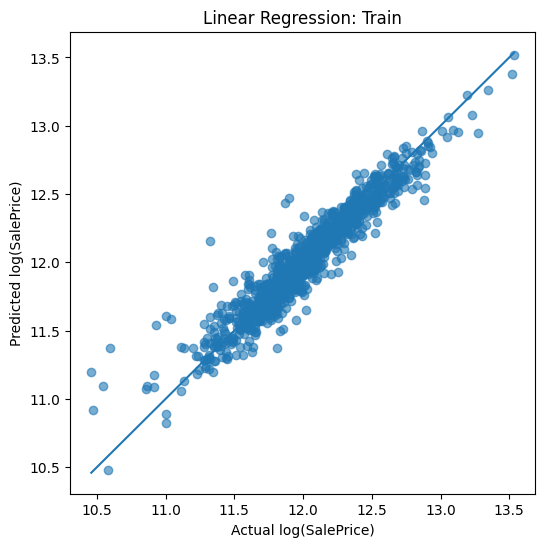

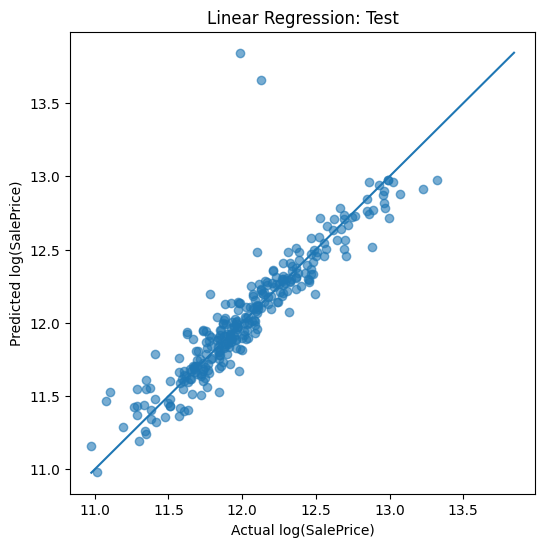

In [ ]:
plot_actual_vs_predicted(y_train, linear_pred_train, "Linear Regression: Train")
plot_actual_vs_predicted(y_test, linear_pred_test, "Linear Regression: Test")

## Ridge Regression

In [23]:
ridge_pipeline.fit(X_train, y_train)

ridge_results, ridge_pred_train, ridge_pred_test = evaluate_model(
    ridge_pipeline, X_train, X_test, y_train, y_test, model_name="Ridge Regression"
)

ridge_results

,R2,RMSE,MAE,Model
Train,0.905674,0.120899,0.084753,Ridge Regression
Test,0.800004,0.188300,0.105077,Ridge Regression


Ridge Regression performance is close to Linear Regression across the metrics. 